In [7]:
conda install -c conda-forge xarray netcdf4

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.7.2

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - netcdf4
    - xarray


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    cftime-1.6.5               |  py314hdd70a12_2         409 KB  conda-forge
    conda-26.7.2               |  py314hcec6336_1         1.4 MB  conda-forge
    hdf4-4.2.13                |       h030b629_4         708 KB
    libaec-1.1.6               |       h550d765_0          28 KB
    libnetcdf-4.10.0           |       h4404923

In [8]:
conda install -c conda-forge cartopy

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - cartopy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cartopy-0.25.0             |np2py314hb9e636f_3         1.5 MB  conda-forge
    geos-3.14.1                |       ha834cd8_0         1.5 MB  conda-forge
    proj-9.8.1                 |       ha88f16d_0         3.0 MB  conda-forge
    pyproj-3.8.0               |  py314h92bd025_1         521 KB  conda-forge
    pyshp-3.1.6                |     pyhcf101f3_0         501 KB  conda-forge
    shapely-2.1.2              |  py314h67cad6a_3         603 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         7.6 MB

The following N

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#Two new packages!
import xarray as xr

In [2]:
import cartopy.crs as ccrs

In [3]:
ds = xr.open_dataset('/Users/rubyestrickland/Desktop/EnvDataSci/HW04/GEOS-CF_AirQuality_20180101_0030z.nc4')

In [4]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [5]:
CO = ds.CO

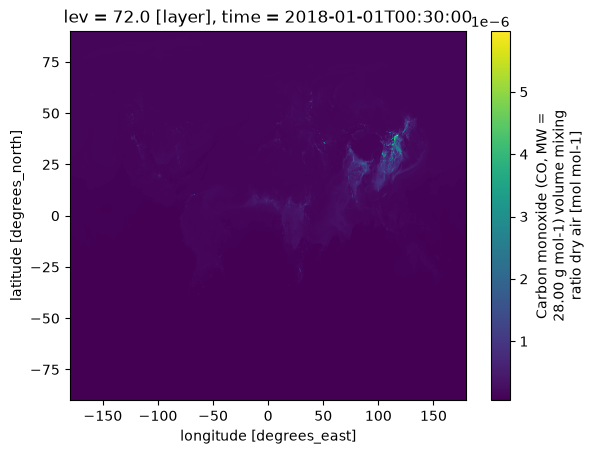

In [6]:
CO.plot()

/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


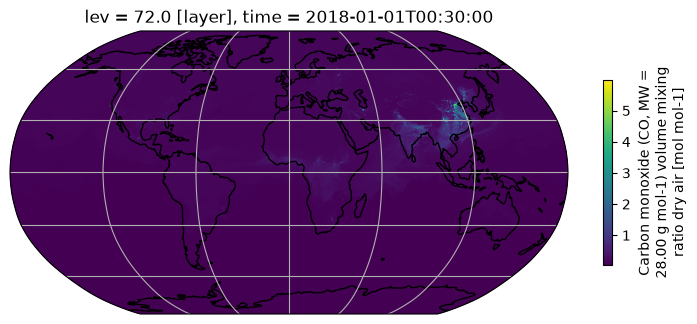

In [7]:
#Elementwise vs matrix operations
CO = ds.CO * 1e6 # convert to ppm

#Plotting basics
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.4}) # This line just makes the axis smaller
ax.coastlines()
ax.gridlines()

/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


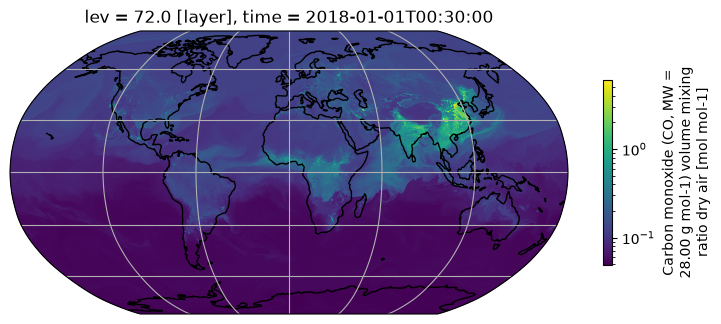

In [8]:
# Let's get log axes!

CO = ds.CO*1e6

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(),
        norm=colors.LogNorm(), # Normalize the colorbar in log scale
        cbar_kwargs={'shrink': 0.4},)
ax.coastlines()
ax.gridlines()

In [9]:
# Select a specific location
# Tucson lat/lon is 32.2540° N, 110.9742° W

CO.sel(lat=[32.2540], lon=[-110.9742], method="nearest")

<xarray.DataArray 'CO' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[0.17340425]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 32.25
  * lon      (lon) float64 8B -111.0
Attributes:
    long_name:       Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [10]:
O3 = ds.O3

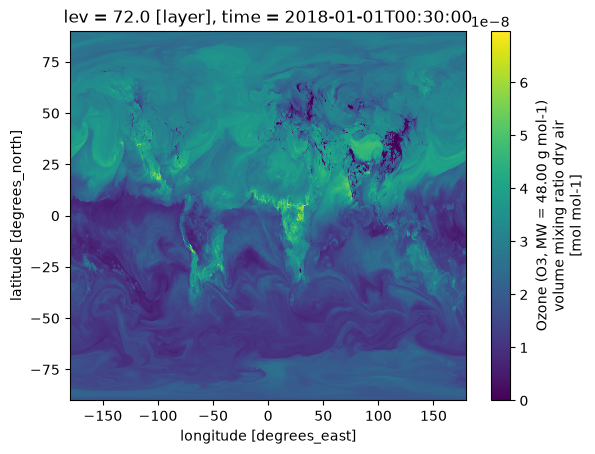

In [11]:
O3.plot()

/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


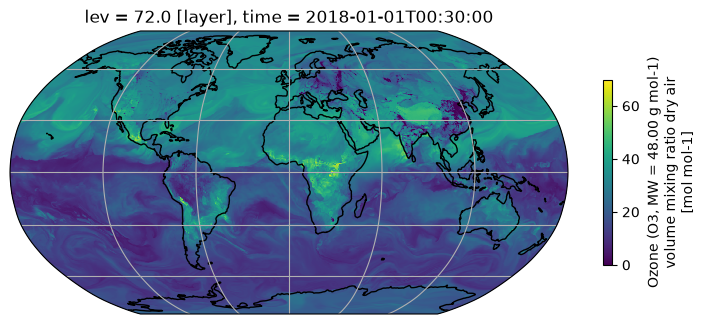

In [26]:
#Elementwise vs matrix operations
O3 = ds.O3 * 1e9 # convert to ppm

#Plotting basics
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.4}) # This line just makes the axis smaller
ax.coastlines()
ax.gridlines()

/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


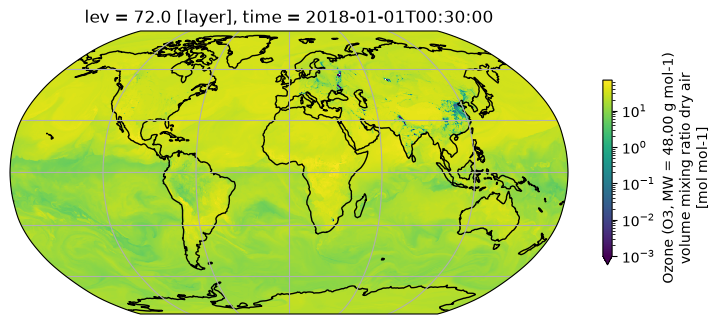

In [28]:
O3 = ds.O3 * 1e9 

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(),
        norm=colors.LogNorm(vmin=1e-3, vmax=O3.max().values), # Normalize the colorbar in log scale
        cbar_kwargs={'shrink': 0.4},)
ax.coastlines()
ax.gridlines()

In [38]:
max_val = ds.O3.max().values
print(f"Highest O3 Value: {max_val}")

Highest O3 Value: 6.973277777433395e-08


In [42]:
min_val = ds.O3.min().values
print(f"Lowest O3 Value: {min_val}")

Lowest O3 Value: 0.0


In [39]:
max_lat = ds.O3.idxmax(dim="lat").values
max_lon = ds.O3.idxmax(dim="lon").values

In [43]:
min_lat = ds.O3.idxmin(dim="lat").values
min_lon = ds.O3.idxmin(dim="lon").values

In [40]:
print(f"Located at Latitude: {max_lat}, Longitude: {max_lon}")

Located at Latitude: [[[31.25 31.25 31.5  ... 31.   31.25 31.25]]], Longitude: [[[-180.   -135.5   -85.25  -81.     57.5    58.75 -163.25 -127.75
   -129.25 -137.   -174.   -175.5  -176.75 -180.    175.75  171.75
    170.    166.25  171.25  160.75  155.5   156.    130.25  129.5
    129.25  128.75  128.    127.25  126.25  124.75  124.      5.5
      6.75    7.25    7.25    7.      7.      6.25    6.    117.25
    116.    116.5   112.25  110.    107.5   106.75  103.     11.
     11.5    11.25   10.75   10.75   10.75   10.75   10.5    10.25
     10.     10.     10.      9.75    9.5     9.75    9.75    7.5
      7.      6.75    6.5     0.5     1.25    2.25    3.      3.25
      6.25    8.25    7.75    5.5     5.75  125.    157.75  156.25
    155.75  127.75  128.    128.5   129.5   128.75  133.25  132.5
    135.    134.75  134.5   135.    137.75  136.    131.    131.
    130.25  129.5   133.5   133.    132.5   132.25  131.5   131.5
    131.    130.75  130.25  129.75  130.25  130.    127.25 

In [44]:
print(f"Located at Latitude: {min_lat}, Longitude: {min_lon}")

Located at Latitude: [[[-12.   -11.75 -12.   ... -11.75 -11.75 -12.  ]]], Longitude: [[[-180.     23.25  112.5     0.5    -4.25  -13.75  -16.5   -14.75
    100.     97.25   95.     94.5    93.25   96.5    95.75   95.
     97.5    94.25   94.25 -147.   -136.5  -140.   -141.   -142.
   -148.5   -60.   -155.    -58.    -58.5   -58.25 -155.25 -154.25
   -155.5  -156.75 -157.75 -158.75 -157.75 -158.75 -159.75  -33.25
    -33.5   -39.75  173.75  -30.25  -29.75  -29.25  -28.75  -27.
    -70.75  -71.25  -73.25  -72.75  -73.5   -73.75  -74.25  -27.75
    -18.25  -22.75  -24.75  -25.5   -26.25  -93.5   -88.25 -139.
   -135.75 -134.   -131.25 -129.5  -129.   -127.5  -127.   -126.5
   -132.   -131.5  -131.25 -131.5  -131.   -131.25 -131.   -131.25
   -131.25 -131.5  -132.   -132.25 -132.75 -128.25  -84.    -85.
    -85.75  -93.    -97.75  -84.25  -85.    -83.25  -83.5   -88.25
    -88.25  -82.75  -82.5   -82.    -81.5   -81.    -79.5   -93.5
    -94.    -94.    -94.25  -94.25  -94.25 -156.75 -155.

In [41]:
max_points_df = O3.where(O3 == O3.max(), drop=True).to_dataframe().dropna()
print(max_points_df)

                                             O3
time                lev  lat  lon              
2018-01-01 00:30:00 72.0 34.5 -118.75  69.73278


In [45]:
min_points_df = O3.where(O3 == O3.min(), drop=True).to_dataframe().dropna()
print(min_points_df)

                                       O3
time                lev  lat   lon       
2018-01-01 00:30:00 72.0 53.00 73.25  0.0
                               73.50  0.0
                         53.25 73.50  0.0
                               73.75  0.0
                         55.75 38.50  0.0
                               39.00  0.0
                               39.25  0.0
                               39.50  0.0
                         56.00 38.75  0.0
                               39.00  0.0
                               39.25  0.0
                               39.50  0.0


In [46]:
O3.sel(lat=[34.0522], lon=[-118.2437], method="nearest")

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[45.401974]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 34.0
  * lon      (lon) float64 8B -118.2
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [46]:
O3.sel(lat=[34.0522], lon=[-118.2437], method="nearest")

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[45.401974]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 34.0
  * lon      (lon) float64 8B -118.2
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [47]:
regional_O3 = O3.sel(lat=slice(18.5, 28.27), lon=slice(-154.48, -178.22))

In [48]:
print(regional_O3)

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 40, lon: 0)> Size: 0B
array([], shape=(1, 1, 40, 0), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 320B 18.5 18.75 19.0 19.25 ... 27.5 27.75 28.0 28.25
  * lon      (lon) float64 0B 
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]


In [52]:
hawaii_mean = regional_O3.mean

In [53]:
print(hawaii_mean)

<bound method DataArrayAggregations.mean of <xarray.DataArray 'O3' (time: 1, lev: 1, lat: 40, lon: 0)> Size: 0B
array([], shape=(1, 1, 40, 0), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 320B 18.5 18.75 19.0 19.25 ... 27.5 27.75 28.0 28.25
  * lon      (lon) float64 0B 
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]>


In [56]:
O3.sel(lat=slice(18.5, 28.27), lon=slice(-154.48, -178.22))

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 40, lon: 0)> Size: 0B
array([], shape=(1, 1, 40, 0), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 320B 18.5 18.75 19.0 19.25 ... 27.5 27.75 28.0 28.25
  * lon      (lon) float64 0B 
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [59]:
total_splice_mean = regional_O3.mean()
print(f"Total Mean Ozone: {float(total_splice_mean):.2f} ppb")

Total Mean Ozone: nan ppb


In [60]:
print(regional_O3.count().values)

0


In [61]:
regional_O3 = O3.sel(lat=slice(18.5, 28.27), lon=slice(-154.48, -178.22))

In [62]:
print(regional_O3.count().values)

0


In [63]:
hawaii_O3 = O3.sel(lat=slice(18, 23), lon=slice(-161, -154))

In [64]:
print(hawaii_O3.count().values)

609


In [65]:
total_splice_mean = hawaii_O3.mean()
print(f"Total Mean Ozone: {float(total_splice_mean):.2f} ppb")

Total Mean Ozone: 35.15 ppb
